   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 1.6 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Logging to ./tb_logs/PPO_selfplay_0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 1791 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1360        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.016920345 |
|    clip_fraction        | 0.311       |
|    clip_range           | 0.2         |
|    entropy_loss         | -3.9        |
|    explained_variance   | -0.119      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0372      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0391     |
|    value_loss           | 0.56        |
-----------------------------------------
----------------------------------

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:284: UserWarning: Path 'models' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


FileNotFoundError: [Errno 2] No such file or directory: 'results/week5_price_trajectory.png'

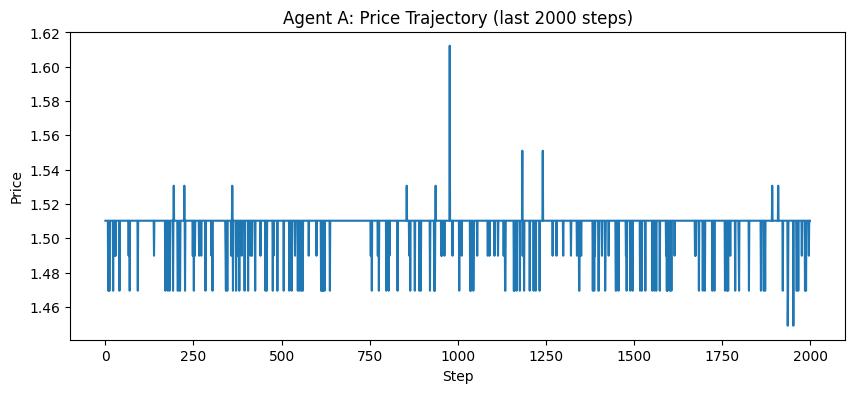

In [4]:
!pip install stable-baselines3
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import torch



# ---------------------------------------------------------
# 1. Custom Pricing Environment (reuse/adapt your Week 2-4 env)
# ---------------------------------------------------------
class PricingDuopolyEnv(gym.Env):
    """
    Two-firm repeated pricing game (Bertrand-style with logit demand),
    following Calvano et al. (2020) setup.
    """
    def __init__(self, n_prices=50, p_min=1.0, p_max=2.0, marginal_cost=1.0,
                 a=2.0, mu=0.25, opponent_policy=None):
        super().__init__()
        self.n_prices = n_prices
        self.price_grid = np.linspace(p_min, p_max, n_prices)
        self.c = marginal_cost
        self.a = a
        self.mu = mu
        self.opponent_policy = opponent_policy  # frozen opponent for self-play

        self.action_space = spaces.Discrete(n_prices)
        # observation: [own_last_price_idx, opp_last_price_idx]
        self.observation_space = spaces.Box(low=0, high=n_prices - 1,
                                             shape=(2,), dtype=np.float32)

        self.own_last = n_prices // 2
        self.opp_last = n_prices // 2

    def _demand(self, p_own, p_opp):
        # logit demand (Calvano et al. 2020)
        num_own = np.exp((self.a - p_own) / self.mu)
        num_opp = np.exp((self.a - p_opp) / self.mu)
        denom = num_own + num_opp + np.exp(0)  # outside option = 0
        q_own = num_own / denom
        return q_own

    def step(self, action):
        p_own = self.price_grid[action]

        if self.opponent_policy is not None:
            opp_action, _ = self.opponent_policy.predict(
                np.array([self.opp_last, self.own_last], dtype=np.float32),
                deterministic=False
            )
            opp_action = int(opp_action)
        else:
            opp_action = np.random.randint(self.n_prices)  # random fallback

        p_opp = self.price_grid[opp_action]

        q_own = self._demand(p_own, p_opp)
        reward = (p_own - self.c) * q_own

        self.own_last, self.opp_last = action, opp_action
        obs = np.array([self.own_last, self.opp_last], dtype=np.float32)

        terminated = False
        truncated = False
        info = {"p_own": p_own, "p_opp": p_opp}
        return obs, reward, terminated, truncated, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.own_last = np.random.randint(self.n_prices)
        self.opp_last = np.random.randint(self.n_prices)
        obs = np.array([self.own_last, self.opp_last], dtype=np.float32)
        return obs, {}


# ---------------------------------------------------------
# 2. Reward/price logging callback (for TensorBoard + plots)
# ---------------------------------------------------------
class PriceLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.own_prices = []
        self.rewards = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [{}])
        if "p_own" in infos[0]:
            self.own_prices.append(infos[0]["p_own"])
        self.rewards.append(self.locals["rewards"][0])
        return True


# ---------------------------------------------------------
# 3. Self-play training loop
# ---------------------------------------------------------
def train_self_play(total_timesteps=100_000, algo="PPO", freeze_every=5000):
    """
    Simultaneous self-play with periodic freezing of one agent
    to reduce non-stationarity (Heinrich & Silver, 2016).
    """
    # Agent B starts random; Agent A trains against it first
    env_a = DummyVecEnv([lambda: PricingDuopolyEnv(opponent_policy=None)])

    if algo == "DQN":
        agent_a = DQN("MlpPolicy", env_a, verbose=1, tensorboard_log="./tb_logs/")
    else:
        agent_a = PPO("MlpPolicy", env_a, verbose=1, tensorboard_log="./tb_logs/")

    callback_a = PriceLoggerCallback()
    chunks = total_timesteps // freeze_every

    for i in range(chunks):
        agent_a.learn(total_timesteps=freeze_every, callback=callback_a,
                      reset_num_timesteps=False, tb_log_name=f"{algo}_selfplay")

        # Freeze agent_a, let agent_b train against frozen copy
        env_b = DummyVecEnv([lambda: PricingDuopolyEnv(opponent_policy=agent_a)])
        if i == 0:
            if algo == "DQN":
                agent_b = DQN("MlpPolicy", env_b, verbose=0, tensorboard_log="./tb_logs/")
            else:
                agent_b = PPO("MlpPolicy", env_b, verbose=0, tensorboard_log="./tb_logs/")
        else:
            agent_b.set_env(env_b)

        agent_b.learn(total_timesteps=freeze_every, reset_num_timesteps=False,
                      tb_log_name=f"{algo}_selfplay_B")

        # Now let agent_a train against updated agent_b
        env_a = DummyVecEnv([lambda: PricingDuopolyEnv(opponent_policy=agent_b)])
        agent_a.set_env(env_a)

        print(f"[{algo}] Round {i+1}/{chunks} complete "
              f"({(i+1)*freeze_every} / {total_timesteps} steps)")

    return agent_a, agent_b, callback_a


# ---------------------------------------------------------
# 4. Run + plot
# ---------------------------------------------------------
if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    agent_a, agent_b, logger = train_self_play(
        total_timesteps=100_000, algo="PPO", freeze_every=5000
    )

    agent_a.save("models/week5_ppo_agent_a")
    agent_b.save("models/week5_ppo_agent_b")

    # Price trajectory plot (last 2000 steps)
    plt.figure(figsize=(10, 4))
    plt.plot(logger.own_prices[-2000:])
    plt.title("Agent A: Price Trajectory (last 2000 steps)")
    plt.xlabel("Step")
    plt.ylabel("Price")
    plt.savefig("results/week5_price_trajectory.png", dpi=150)
    plt.show()

    print("Training complete. Models saved to /models, plot saved to /results.")